In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [2]:
load_dotenv()  # Load environment variables from .env file

True

In [3]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [4]:
from langgraph.store.memory import InMemoryStore
store = InMemoryStore()

In [6]:
namespace = ("users", "harshit")

In [7]:
store.put(namespace, "name", {"data" : "User full name is Harshit Rai."})
store.put(namespace, "email", {"data" : "User email is raiharshit66@gmail.com"})

In [8]:
#getting 
print(store.get(namespace, "name"))

Item(namespace=['users', 'harshit'], key='name', value={'data': 'User full name is Harshit Rai.'}, created_at='2026-10-05T17:21:06.925600+00:00', updated_at='2026-10-05T17:21:06.925600+00:00')


In [10]:
#search
items = store.search(namespace)
for item in items:
    print(item.key,": ", item.value)

name :  {'data': 'User full name is Harshit Rai.'}
email :  {'data': 'User email is raiharshit66@gmail.com'}


### Semantic Search

In [11]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview", output_dimensionality=1536)


In [12]:
semantic_store = InMemoryStore(index={"embed" : embeddings, "dims":1536})

In [13]:
namespace = ("users", "harshit")
semantic_store.put(namespace, "name", {"data" : "User full name is Harshit Rai."})
semantic_store.put(namespace, "email", {"data": "User email is raiharshit66@gmail.com"})
semantic_store.put(namespace, "age", {"data": "User is 28 years old."})
semantic_store.put(namespace, "location", {"data": "User lives in Bengaluru, India."})
semantic_store.put(namespace, "profession", {"data": "User works as a software engineer."})
semantic_store.put(namespace, "hobbies", {"data": "User enjoys photography, hiking, and reading."})
semantic_store.put(namespace, "favorite_food", {"data": "User's favorite foods are biryani and pizza."})
semantic_store.put(namespace, "preferred_language", {"data": "User prefers communicating in English and Hindi."})

In [14]:
semantic_store.put(namespace, "programming_languages", {
    "data": "User programs in Python, JavaScript, and TypeScript."
})
semantic_store.put(namespace, "frameworks", {
    "data": "User works with LangChain, LangGraph, FastAPI, and React."
})
semantic_store.put(namespace, "databases", {
    "data": "User has experience with PostgreSQL, MongoDB, and Redis."
})
semantic_store.put(namespace, "development_tools", {
    "data": "User uses Git, Docker, Jupyter Notebook, and Visual Studio Code."
})
semantic_store.put(namespace, "programming_interests", {
    "data": "User is interested in artificial intelligence, machine learning, and agentic applications."
})
semantic_store.put(namespace, "career_goal", {
    "data": "User wants to build production-ready AI applications and intelligent software agents."
})

In [17]:
query = "What is the user's favorite food?"
results = semantic_store.search(namespace, query=query, limit=1)
for result in results:
    print(result.key, ": ", result.value)

favorite_food :  {'data': "User's favorite foods are biryani and pizza."}


In [18]:
query="What are user's programming preferences?"
results = semantic_store.search(namespace, query=query, limit=2)
for result in results:
    print(result.key, ": ", result.value)

development_tools :  {'data': 'User uses Git, Docker, Jupyter Notebook, and Visual Studio Code.'}
programming_languages :  {'data': 'User programs in Python, JavaScript, and TypeScript.'}


### LLM - Memory Creation

In [19]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [20]:
from pydantic import BaseModel, Field
class MemoryDecisionModel(BaseModel):
    should_write: bool = Field(..., description="Indicates whether the memory should be written or not.")
    memory_points: list[str] = Field(default_factory=list, description="List of memory points to be written if should_write is True.")

In [21]:
extractor_llm = llm.with_structured_output(MemoryDecisionModel)

In [39]:
from langgraph.store.base import BaseStore
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

def decide_memory_write(state:MessagesState, config:RunnableConfig, store:BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("users", user_id)

    last_message = state["messages"][-1].text

    decision = extractor_llm.invoke([
        SystemMessage(
            content=(
                """Extract Long-Term Memory points from the user's message.
                Only extract points that are relevant to the user's personal information, preferences, or experiences.
                Don't store transient information or temporary states. If the message doesn't contain any relevant information, return should_write as False and an empty list of memory_points.
                Each memory point should be a concise statement that can be stored in the memory store for future reference.
                """
            )
        ),
        {"role": "user", "content": last_message}
    ])

    if decision.should_write:
        for i, point in enumerate(decision.memory_points):
            print(f"{i+1} : {point}")
            store.put(namespace, str(hash(point)), {"data": point})  

    return {"messages": [{"role": "assistant", "content": "Memory points have been processed and stored."}]}

In [40]:
graph = StateGraph(MessagesState)

graph.add_node("memory_write", decide_memory_write)
graph.add_edge(START, "memory_write")
graph.add_edge("memory_write", END)

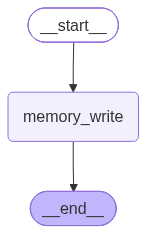

In [41]:
store_2 = InMemoryStore()
workflow = graph.compile(store=store_2)
workflow

In [42]:
user_id = "harshit"
config = RunnableConfig(configurable={"user_id": user_id, "thread_id": "thread_1"})
while True:
    user_input = input("User: ")
    user_input = user_input.strip()
    print("User:", user_input) 
    exit_words = ["exit", "quit", "bye" , "0"]
    if user_input.lower() in exit_words:
        print("Exiting the conversation.")
        break
    
    output = workflow.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    print("Assistant:", output["messages"][-1].text)

User: Hi I am Harshit, I prefer coding in C++
1 : User's name is Harshit
2 : User prefers coding in C++
Assistant: Memory points have been processed and stored.
User: 0
Exiting the conversation.
